### Kapitel 1 - koduppgift 11

1. I koden nedan använder vi först test_size=0.2 och sedan test_size=0.25,
förklara varför det ger oss proportionerna 60-20-20.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=10, random_state=42)

X_train, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train_full, test_size=0.25, random_state=42)

In [2]:
print("Total amount of observations: ", len(X))
print("Training: ", len(X_train))
print("Validation: ", len(X_val))
print("Testing: ", len(X_test))

Total amount of observations:  100
Training:  60
Validation:  20
Testing:  20


Genom att sätta test_size=0.2 i första steget bryter ja ut 20% till testdata och behåller 80% för träning. För att valideringsdatan i steg två ska 20% av den ursprungliga totalen, måste vi ta en fjärdedel av det som är kvar. Då 25% av 80% är 20%, resulterar detta i den önskade 60-20-20-fördelningen.

### Kapitel 2 - koduppgift 8

2. Förklara vad koden nedan gör. Varför är det viktigt att kunna spara en
modell

In [3]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from joblib import dump, load
4
X, y = make_regression(n_samples=20000, n_features=3,

noise=0.1)
model = LinearRegression().fit(X, y)
dump(model, "linear_model.joblib")
model_loaded = load("linear_model.joblib")
print(model_loaded.predict(X[:5]))

[-197.12898507   22.52795263  -63.46722177  -60.99343167   37.69542215]


Koden hämtar verktyg för att skapa data och träna en linjär regressionsmodell. Efter träningen sparas modellens "hjärna" som en fil med funktionen dump och laddas sedan in igen med load för att göra förutsägelser. Detta är avgörande eftersom det sparar enormt mycket tid och datorkraft då man slipper träna om modellen varje gång den ska användas. Genom att spara modellen kan den enkelt flyttas till appar eller servrar och delas med andra utan att man behöver ha kvar den ursprungliga träningsdatan

### Kapitel 2 - Koduppgift 9

In [5]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.model_selection import cross_validate

df= pd.read_csv("data_01.csv") 
print(df.head())

         x1        x2        x3        x4        x5      target
0  0.743487  1.072825  1.332911 -1.244771  0.344978  220.173943
1  0.835264  0.202184  0.966480  0.745883 -0.033773  175.873929
2 -1.103234  0.030615 -0.140385  0.727683 -2.831224 -162.270054
3  1.210186  1.685258 -0.394123  0.719024 -2.166585  165.930461
4  0.474577  0.647737 -0.451812 -0.409472 -0.051473   43.250511


In [6]:
X = df.drop("target", axis=1)
y = df["target"]

In [7]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1875, random_state=42)

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

lin_reg = LinearRegression()
tree_reg = DecisionTreeRegressor(random_state=42)

lin_reg.fit(X_train, y_train)
tree_reg.fit(X_train, y_train) 

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [9]:
from sklearn.metrics import root_mean_squared_error

rmse_linreg = root_mean_squared_error(y_val, lin_reg.predict(X_val))
rmse_tree = root_mean_squared_error(y_val, tree_reg.predict(X_val))

print("RMSE Linear Regression: ", rmse_linreg)
print("RMSE Decision Tree: ", rmse_tree)

RMSE Linear Regression:  3.3240790627529275
RMSE Decision Tree:  96.01575547055431


In [10]:
if rmse_linreg < rmse_tree:
    best_model = LinearRegression()
    best_model_name = "Linjär Regression"
else:
    best_model = DecisionTreeRegressor(random_state=42)
    best_model_name = "Beslutsträd"
    
print("The best model is: ", best_model_name)

The best model is:  Linjär Regression


In [11]:
best_model.fit(X_train_full, y_train_full)    

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
rmse_test = root_mean_squared_error(y_test,
best_model.predict(X_test))
print(f"Bästa modell baserat på validering: {best_model_name}")
print(f"RMSE på testdatan: {rmse_test:.2f}")

Bästa modell baserat på validering: Linjär Regression
RMSE på testdatan: 3.37


In [13]:
best_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Kapitel 2 - uppgift 10

In [15]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.model_selection import cross_validate

df= pd.read_csv("salary_dataset.csv") 
print(df.head())

X = df[["Salary"]]
y = df["YearsExperience"]

   YearsExperience   Salary
0              1.2  39344.0
1              1.4  46206.0
2              1.6  37732.0
3              2.1  43526.0
4              2.3  39892.0


In [16]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Skapa modellerna
model_lr = LinearRegression()
model_tree = DecisionTreeRegressor()

# Kör korsvalidering för Linjär Regression
cv_results_lr = cross_validate(
    model_lr, X_train, y_train, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    return_train_score=True
)

# Kör korsvalidering för Beslutsträd
cv_results_tree = cross_validate(
    model_tree, X_train, y_train, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    return_train_score=True
)

In [25]:
if np.mean(cv_results_lr['test_score']) > np.mean(cv_results_tree['test_score']):
    print("The best model is linear regression.")
elif np.mean(cv_results_lr['test_score']) == np.mean(cv_results_tree['test_score']):
    print("The models are equally good.")
else:
    print("The best model is decision tree.")

The best model is linear regression.


### Kapitel 2 - uppgift 11

In [30]:
# A
import pandas as pd
import ssl
import seaborn as sns

ssl._create_default_https_context = ssl._create_unverified_context
df = sns.load_dataset("mpg")
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [31]:
# B
df = df.dropna()
print(f"Antal rader efter dropna: {len(df)}")
print(df.isnull().sum())

Antal rader efter dropna: 392
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [32]:
# C
df = df.drop(columns=["name"])
print(df.columns)

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin'],
      dtype='object')


In [33]:
# D
df = pd.get_dummies(df, columns=['origin'], drop_first=True, dtype=int)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,0,1


In [34]:
# E
y = df["mpg"]
X = df.drop(columns=["mpg"])
print(f"X har nu {X.shape[1]} kolumner: {list(X.columns)}")

X har nu 8 kolumner: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']


In [35]:
# F
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Träningsdata: {X_train.shape[0]} bilar")
print(f"Testdata: {X_test.shape[0]} bilar")

Träningsdata: 313 bilar
Testdata: 79 bilar


In [36]:
#G
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)
print(f"RMSE på testdata: {rmse:.2f}")

RMSE på testdata: 10.60


### Kapitel 3 - uppgift 13

--- Personalöversikt ---
left
0    0.761917
1    0.238083
Name: proportion, dtype: float64


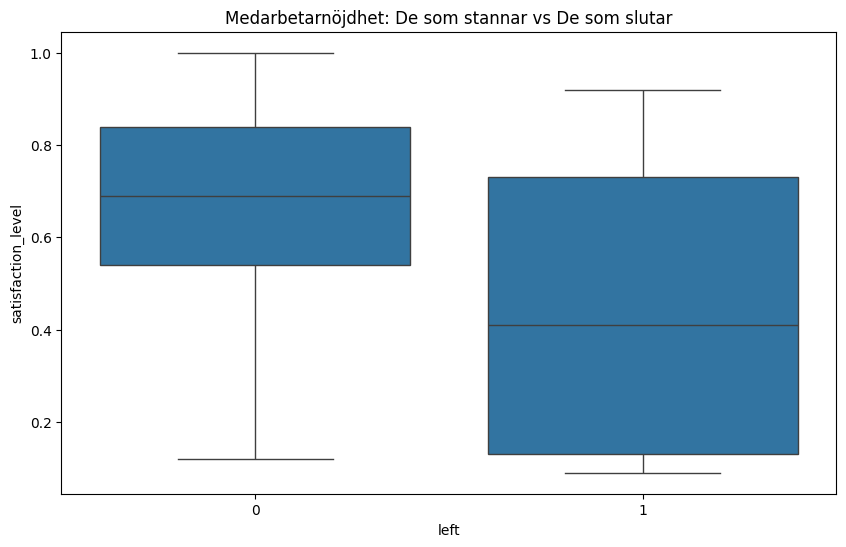

<Figure size 1000x600 with 0 Axes>

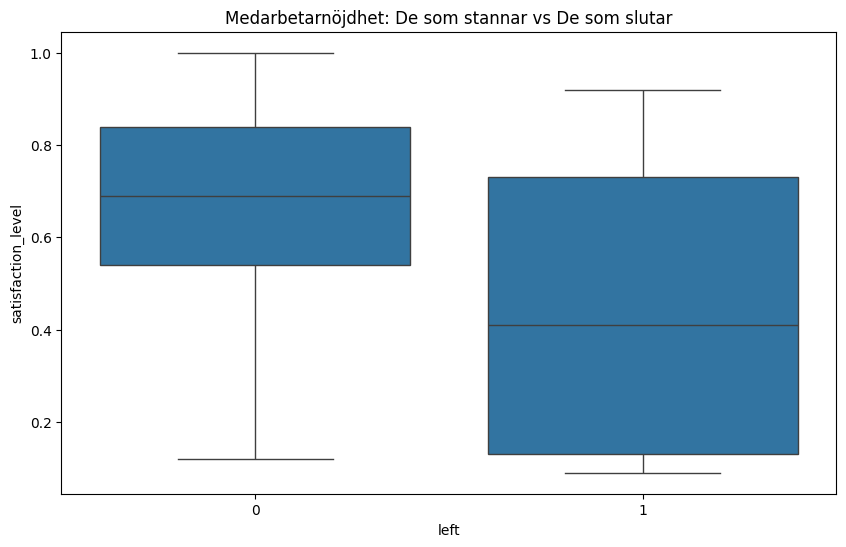

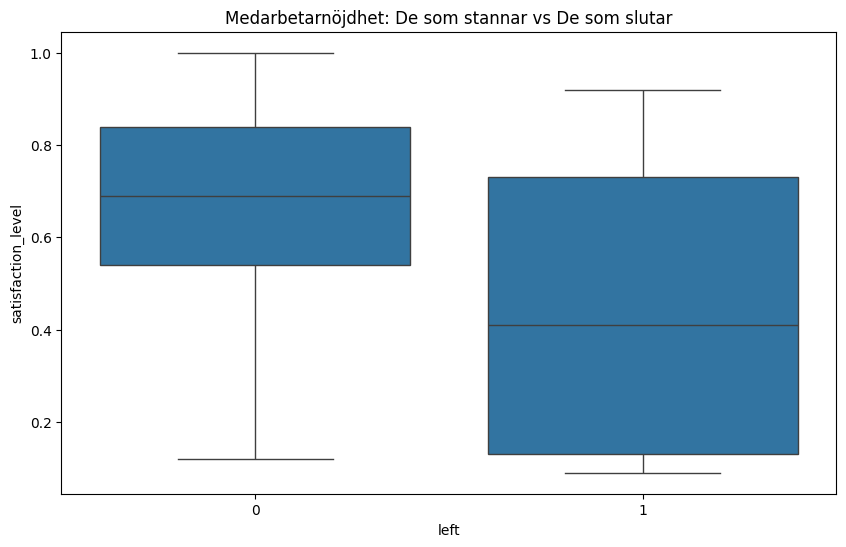

<Figure size 1000x600 with 0 Axes>

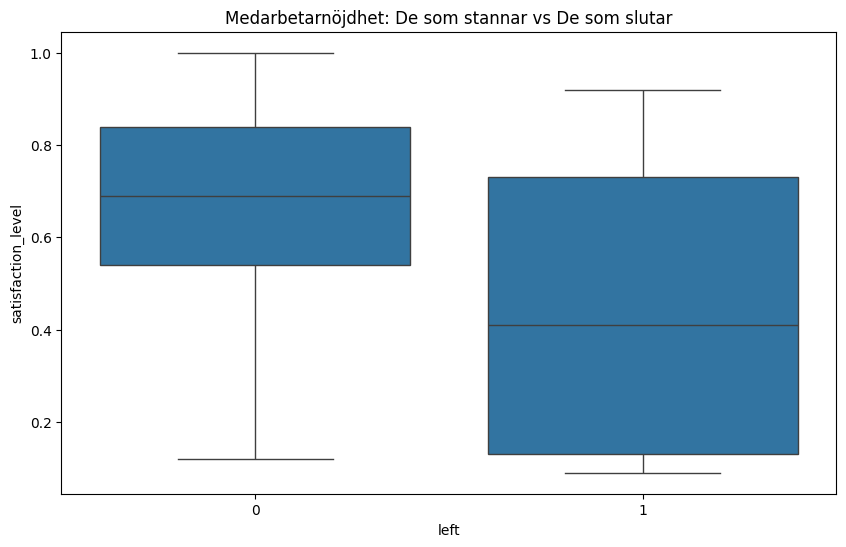

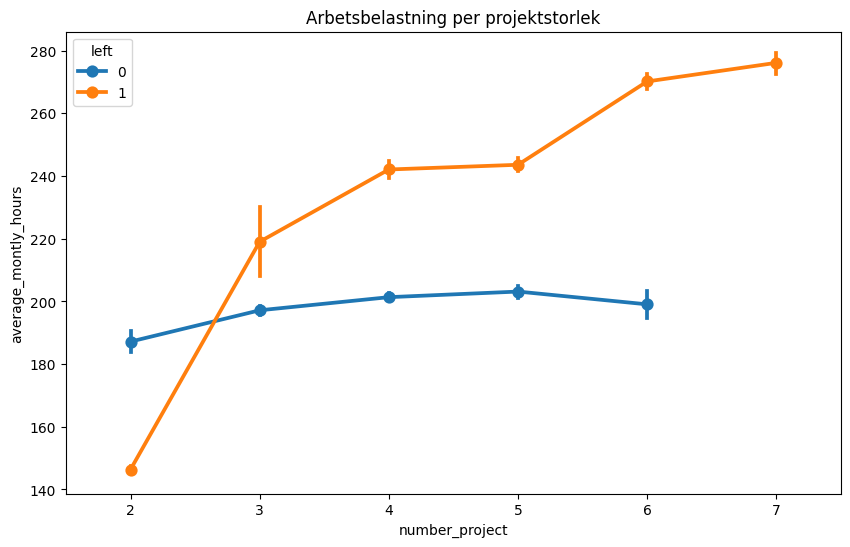

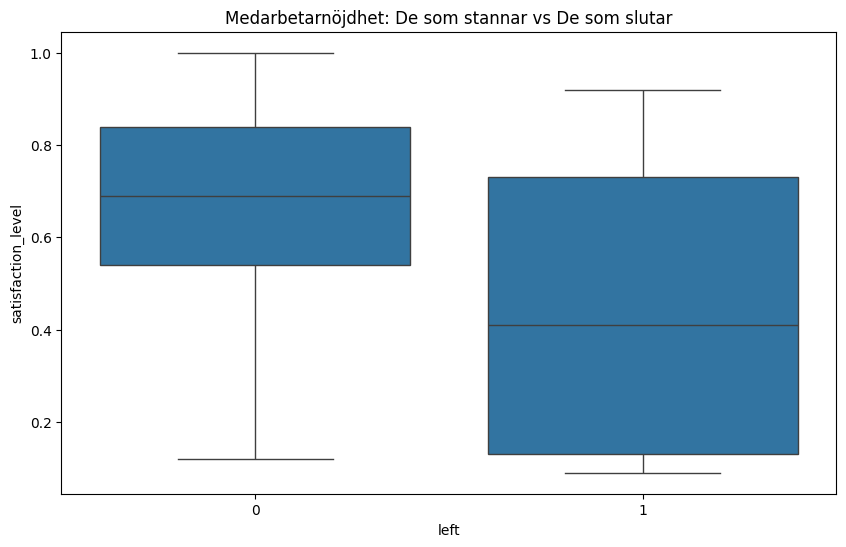

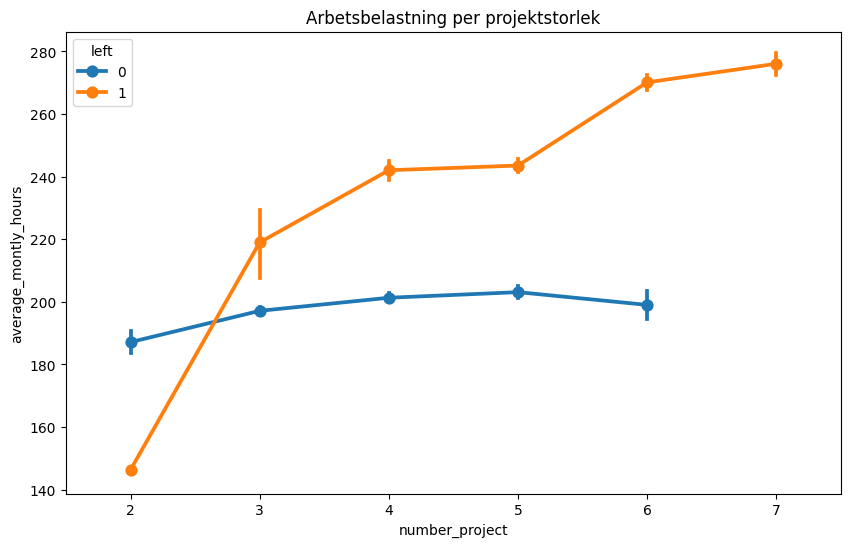

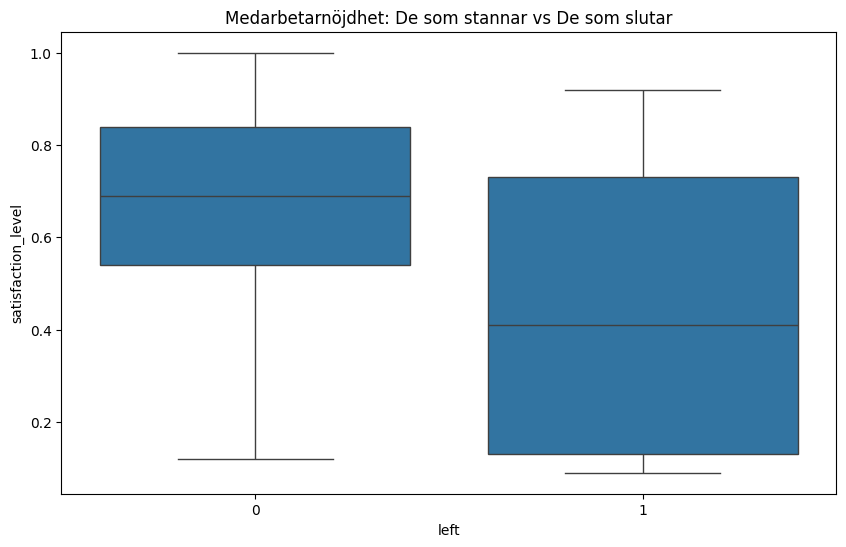

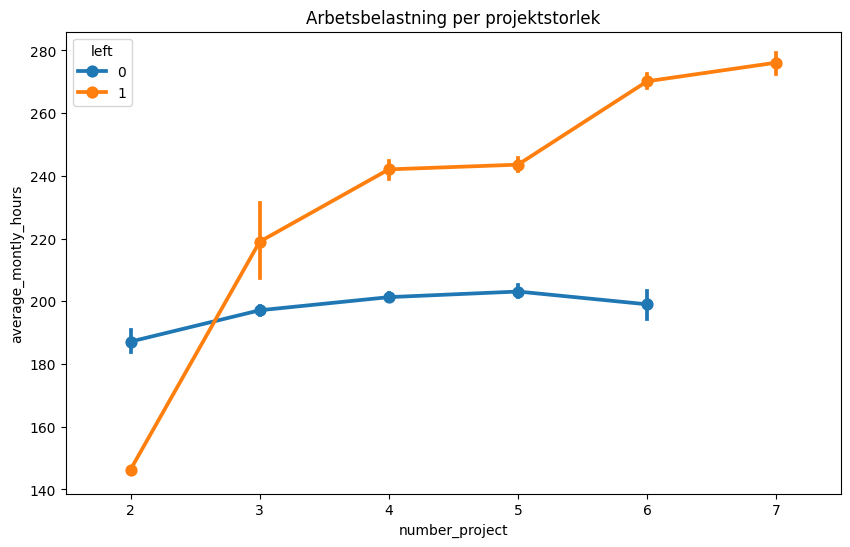

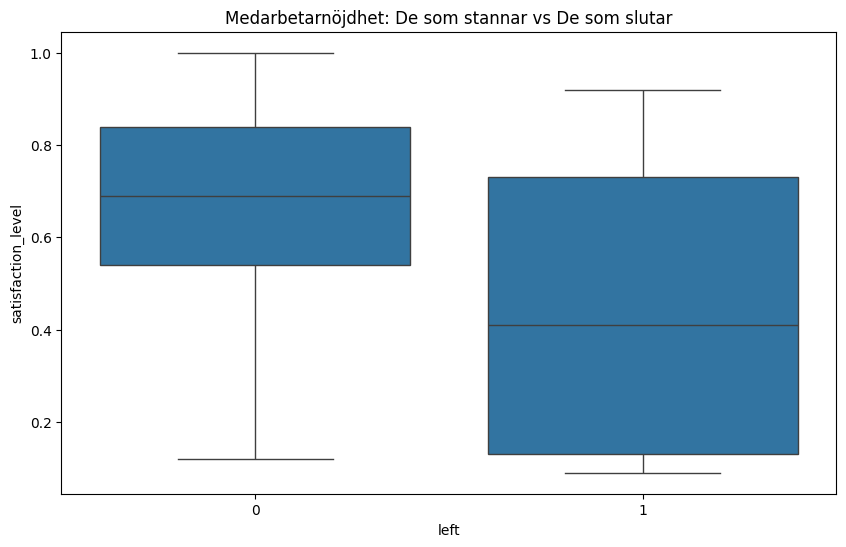

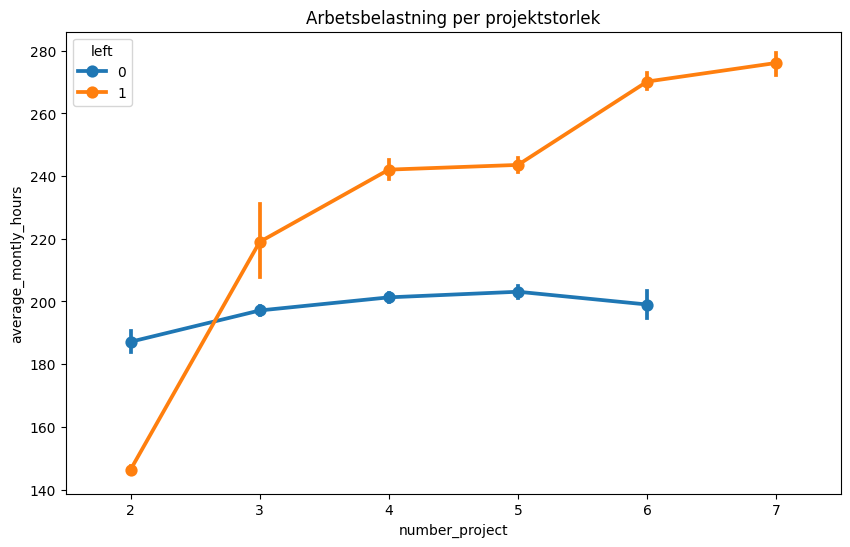

In [24]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ladda data
df = pd.read_excel('hr_employee_data.xlsx')

# Övergripande statistik för ledningen
print("--- Personalöversikt ---")
print(df['left'].value_counts(normalize=True)) # Visar % som slutat

# Visualisering: Nöjdhet vs Personalomsättning
plt.figure(figsize=(10,6))
sns.boxplot(x='left', y='satisfaction_level', data=df)
plt.title('Medarbetarnöjdhet: De som stannar vs De som slutar')
plt.show()

# Visualisering: Arbetstid vs Antal projekt
plt.figure(figsize=(10,6))
sns.pointplot(x='number_project', y='average_montly_hours', hue='left', data=df)
plt.title('Arbetsbelastning per projektstorlek')
plt.show()


### Kapitel 3 - uppgift 14

In [64]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
# This code is merely executed to see the description of the data in a smooth way
data = load_diabetes()
print(data.DESCR)
# Storing/loading the data the way it will be used
X, y = load_diabetes(return_X_y=True, as_frame=True)
print(X.info())
print(y.info())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Initiera modellen
model = LinearRegression()

# 2. Träna modellen med träningsdatan
model.fit(X_train, y_train)

# 3. Gör förutsägelser på testdatan
y_pred = model.predict(X_test)

# 4. Utvärdera modellen
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Modellens RMSE (felmarginal): {rmse:.2f}")
print(f"R2-score (förklaringsgrad): {r2:.2f}")

Modellens RMSE (felmarginal): 53.85
R2-score (förklaringsgrad): 0.45


### kapitel 3 - uppgift 15

In [ ]:
#A)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("car_price_dataset.csv", sep=";")
df.head()


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [ ]:
# Gör om textkategorier till siffror
df_prepared = pd.get_dummies(df, drop_first=True)

# Definiera X (allt utom priset) och y (priset vi vill gissa)
X = df_prepared.drop('Price', axis=1)
y = df_prepared['Price']

# Dela upp i träning test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data förberedd! Träningssetet har", X_train.shape[0], "rader.")

Data förberedd! Träningssetet har 8000 rader.


In [10]:
# Skapa och träna modellen
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Genomsnittligt fel (MAE): {mae:.0f} kr")
print(f"Modellens förklaringsgrad (R2): {r2:.2f}")

Genomsnittligt fel (MAE): 439 kr
Modellens förklaringsgrad (R2): 0.97


In [12]:
# B)
import pickle

# Spara modellen till en fil
with open('car_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Spara kolumnnamnen 
model_columns = list(X.columns)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(model_columns, f)

In [ ]:
# C) Står i text dokumentet

### Kapitel 4 - Uppgift 11

Koden utvärderar hur bra en maskininlärningsmodell har presterat genom att jämföra "facit" med modellens gissningar.

y_true: Detta är de faktiska värdena (sanningen). Det finns 5 observationer totalt: en av klass 0, en av klass 1 och tre av klass 2.

y_pred: Detta är vad modellen har gissat för samma 5 observationer.

classification_report: Detta är en funktion som sammanställer statistik för att visa var modellen är träffsäker och var den gör fel. Den bryter ner resultatet klass för klass.


Genom att jämföra y_true med modellens gissningar i y_pred ser jag att den totala träffsäkerheten (accuracy) landar på 60 procent. För att förstå vad som döljer sig bakom siffran har jag analyserat resultatet klass för klass.

För klass 2 är modellen stabil med en perfekt precision på 1.00, vilket betyder att den aldrig gissade fel på den klassen. Däremot är recall 0.67, så den missade ett av tre faktiska fall. För klass 0 är läget det omvända; modellen hittade det enda fallet som fanns (recall 1.00), men fick en låg precision på 0.50 eftersom den även gissade på noll när det var fel.

Det största problemet är klass 1, där modellen har noll i alla värden. Den enda ettan som fanns i datat gissades istället vara en nolla. Min slutsats är att modellen är obalanserad och har svårt att skilja på klass 0 och 1, vilket jag skulle behöva åtgärda genom att antingen balansera träningsdatan eller undersöka om klasserna liknar varandra för mycket

### Kapitel 4 - Uppgift 12


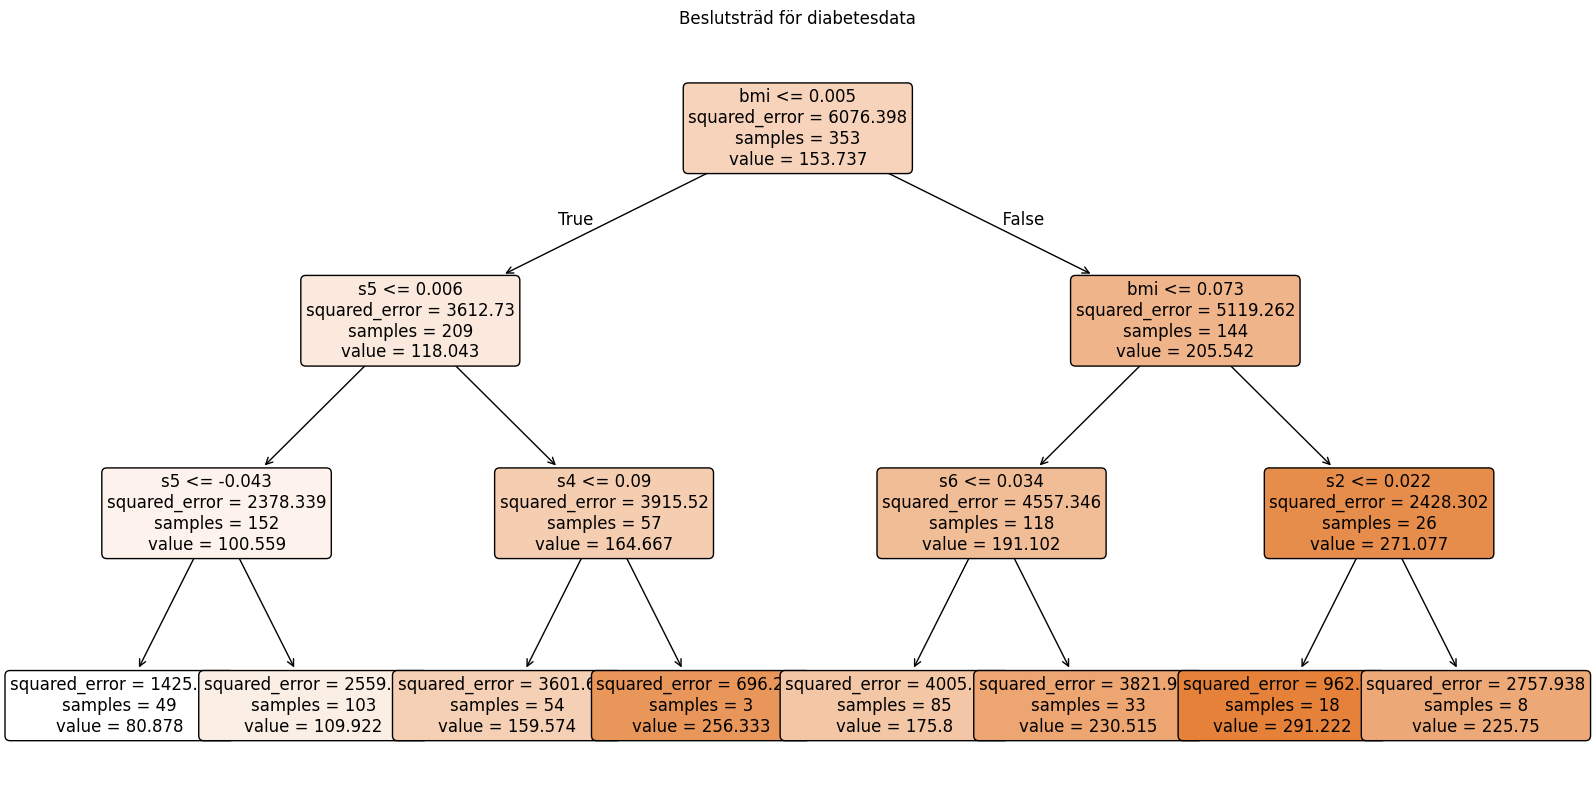

In [66]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns, filled=True, rounded=True, fontsize=12)
plt.title("Beslutsträd för diabetesdata")
plt.show()

### Kapitel 4 - Uppgift 13

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_excel('hr_employee_data.xlsx')

# göra om text till siffror
df_final = pd.get_dummies(df, drop_first=True)

# Definiera X och y
X = df_final.drop('left', axis=1)
y = df_final['left']

# Dela upp i träning och test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Träna modellen
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Utvärdera
y_pred = model.predict(X_test)

print(f"Modellens träffsäkerhet: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetaljerad rapport:")
print(classification_report(y_test, y_pred))

Modellens träffsäkerhet: 0.97

Detaljerad rapport:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2294
           1       0.98      0.91      0.94       706

    accuracy                           0.97      3000
   macro avg       0.98      0.95      0.96      3000
weighted avg       0.98      0.97      0.97      3000



### Kapitel 4 - Uppgift 14

--- Modellutvärdering: Iris ---
Accuracy på valideringsdata: 0.64

Detaljerad rapport:
              precision    recall  f1-score   support

      setosa       0.83      1.00      0.91        10
  versicolor       0.47      0.75      0.58        12
   virginica       0.80      0.29      0.42        14

    accuracy                           0.64        36
   macro avg       0.70      0.68      0.64        36
weighted avg       0.70      0.64      0.61        36



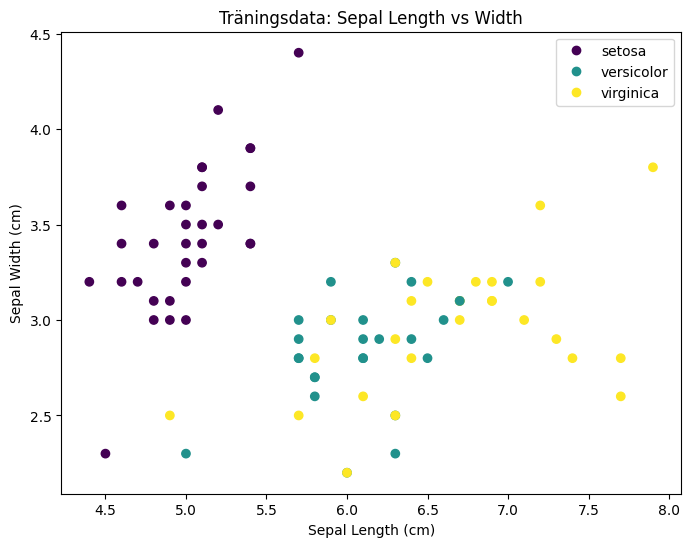

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. LADDA OCH FÖRBERED DATA
iris = load_iris()
X, y = load_iris(return_X_y=True, as_frame=True)

# Vi väljer två variabler för att hålla det enkelt (enligt din startkod)
X_subset = X[['sepal length (cm)', 'sepal width (cm)']]

# 2. DELA UPP DATA (Train, Validation, Test)
# Först dela upp i Training+Validation och Test
X_train_full, X_test, y_train_full, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=40)

# Dela sedan upp Training+Validation i en ren träningsdel och en valideringsdel
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

# 3. TRÄNA MODELLEN (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 4. GÖR FÖRUTSÄGELSER OCH UTVÄRDERA
y_val_pred = knn.predict(X_val)

print("--- Modellutvärdering: Iris ---")
print(f"Accuracy på valideringsdata: {accuracy_score(y_val, y_val_pred):.2f}")
print("\nDetaljerad rapport:")
print(classification_report(y_val, y_val_pred, target_names=iris.target_names))

# 5. VISUALISERING (Scatter plot)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Träningsdata: Sepal Length vs Width')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.show()